# 11. Bayesian Inference for Decision Making

Bayesian inference is often introduced as a way to update beliefs. In practice, its real value is sharper than that: it lets us translate uncertainty into concrete decisions when actions, costs, and prior knowledge all matter.


## Learning Objectives

After working through this lecture, you should be able to:

- explain how priors, likelihoods, and posteriors work together in a decision problem,
- compute and interpret Bayesian posterior summaries for event rates,
- distinguish posterior uncertainty about parameters from predictive uncertainty about future outcomes,
- evaluate an action using posterior expected value and probability-of-success criteria,
- assess whether a decision is robust to reasonable prior choices.


In [1]:
# Load the libraries and notebook settings used in the examples below.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import beta

# Keep displayed tables readable in the rendered lecture notes.
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", None)

sns.set_theme(style="whitegrid", context="notebook")

# Use stable colors so current workflow, gate workflow, and posterior summaries stay visually distinct.
COLORS = {
    "current": "#b45309",
    "gate": "#15803d",
    "posterior": "#1d4ed8",
    "baseline": "#0f172a",
    "accent": "#7c3aed",
}


def beta_posterior(prior_a, prior_b, successes, trials):
    """
    Update a beta prior after observing a binomial count.

    Parameters:
        prior_a: Prior pseudo-count for Sev-1 incident releases.
        prior_b: Prior pseudo-count for non-Sev-1 releases.
        successes: Observed number of Sev-1 incident releases.
        trials: Total number of releases observed in the workflow arm.

    Returns:
        Posterior beta parameters `(a_post, b_post)` after adding observed incidents and non-incidents to the prior.

    Idea:
        Beta-binomial conjugacy keeps the Bayesian update transparent enough to inspect by hand while still producing full posterior uncertainty.
    """
    return prior_a + successes, prior_b + trials - successes


def posterior_interval(alpha, beta_param, level=0.90):
    """
    Compute equal-tailed credible limits for a beta posterior.

    Parameters:
        alpha: Posterior alpha parameter for the beta distribution.
        beta_param: Posterior beta parameter for the beta distribution.
        level: Credible mass to keep inside the interval.

    Returns:
        Lower and upper posterior quantiles that contain the requested credible mass.

    Idea:
        Credible intervals turn posterior distributions into compact probability statements for decision briefings.
    """
    lower = (1 - level) / 2
    upper = 1 - lower
    return beta.ppf(lower, alpha, beta_param), beta.ppf(upper, alpha, beta_param)


## 1. Why Bayesian Inference Is Naturally Decision-Oriented

In many operational settings, data alone do not settle the decision. Leaders typically care about questions such as:

- What do we already know before the pilot starts?
- How much uncertainty remains after the pilot?
- What is the probability that an intervention is genuinely better?
- Is the likely gain large enough to justify rollout costs?

A Bayesian workflow addresses these questions directly because it represents uncertainty with a posterior distribution and then evaluates actions under that distribution.

The inferential logic is

$$
p(\theta \mid y) \propto p(y \mid \theta) p(\theta),
$$

where:

- $p(\theta)$ is the prior,
- $p(y \mid \theta)$ is the likelihood,
- $p(\theta \mid y)$ is the posterior.

Once the posterior is available, a Bayesian action rule chooses the decision $a$ that maximizes posterior expected utility:

$$
a^* = \arg\max_a \; \mathbb{E}[U(a, \theta) \mid y].
$$

That last step is what makes Bayesian inference particularly attractive for decision science: the analysis does not stop at estimation.


## 2. Case Study: Should We Roll Out a Release-Gating Workflow?

A software platform team is piloting a new release-gating workflow designed to reduce **Sev-1 launch incidents**. Leadership wants to know whether the gate should be deployed across all production releases.

The decision is not purely statistical:

- rolling out the gate requires engineering time and operational retraining,
- the pilot sample is informative but not huge,
- prior experience suggests the gate might help, but perhaps only modestly.

We will compare the current workflow against the gated workflow using a Beta-Binomial model.

### Variable Guide

| Quantity | Meaning | Why it matters |
| --- | --- | --- |
| `n_releases` | Number of releases observed in a workflow arm | Controls how much new evidence enters the posterior |
| `sev1_releases` | Releases that triggered a Sev-1 incident | Primary binary failure outcome |
| `theta` | Latent incident probability for a workflow | The parameter we care about for decisions |
| `prior_a`, `prior_b` | Beta prior parameters | Encode historical knowledge and prior confidence |
| `delta = theta_current - theta_gate` | Improvement from gating | Positive values mean the gate lowers incident risk |


## 3. Priors and Observed Pilot Data

We use Beta priors because they are conjugate to the Binomial likelihood. If

$$
\theta \sim \text{Beta}(a, b), \qquad y \mid \theta \sim \text{Binomial}(n, \theta),
$$

then the posterior is

$$
\theta \mid y \sim \text{Beta}(a + y, b + n - y).
$$

For the current workflow, prior experience centers incident risk around 30%. For the gated workflow, the prior is mildly optimistic but not aggressive: it centers risk around roughly 23%.


In [2]:
# Create the pilot table and perform the beta-binomial update for each workflow.
pilot = pd.DataFrame(
    [
        {
            "workflow": "Current workflow",
            "prior_a": 18,
            "prior_b": 42,
            "n_releases": 70,
            "sev1_releases": 21,
        },
        {
            "workflow": "Release gate",
            "prior_a": 14,
            "prior_b": 46,
            "n_releases": 65,
            "sev1_releases": 14,
        },
    ]
)

# Prior means summarize historical expectations; observed rates summarize the pilot evidence.
pilot["prior_mean"] = pilot["prior_a"] / (pilot["prior_a"] + pilot["prior_b"])
pilot["observed_rate"] = pilot["sev1_releases"] / pilot["n_releases"]

# Conjugacy lets the posterior parameters be computed by adding incident and non-incident counts.
pilot["posterior_a"] = pilot["prior_a"] + pilot["sev1_releases"]
pilot["posterior_b"] = pilot["prior_b"] + pilot["n_releases"] - pilot["sev1_releases"]
pilot["posterior_mean"] = pilot["posterior_a"] / (pilot["posterior_a"] + pilot["posterior_b"])
pilot["prior_strength"] = pilot["prior_a"] + pilot["prior_b"]

intervals = pilot.apply(
    lambda row: posterior_interval(row["posterior_a"], row["posterior_b"], level=0.90),
    axis=1,
)
pilot["posterior_90_lower"] = [x[0] for x in intervals]
pilot["posterior_90_upper"] = [x[1] for x in intervals]

pilot_display = pilot[
    [
        "workflow",
        "prior_strength",
        "prior_mean",
        "n_releases",
        "sev1_releases",
        "observed_rate",
        "posterior_mean",
        "posterior_90_lower",
        "posterior_90_upper",
    ]
].copy()

display(pilot_display.round(3))


,workflow,prior_strength,prior_mean,n_releases,sev1_releases,observed_rate,posterior_mean,posterior_90_lower,posterior_90_upper
0,Current workflow,60,0.300,70,21,0.300,0.300,0.236,0.368
1,Release gate,60,0.233,65,14,0.215,0.224,0.165,0.288


The update has two different patterns. For the current workflow, the prior mean and observed pilot rate are both 0.30, so the posterior mean remains at 0.30 while uncertainty narrows. For the release gate, the observed incident rate is slightly lower than its already optimistic prior mean, so the posterior moves downward only modestly. That is what the beta-binomial update does: evidence changes the prior, but it does not erase it.

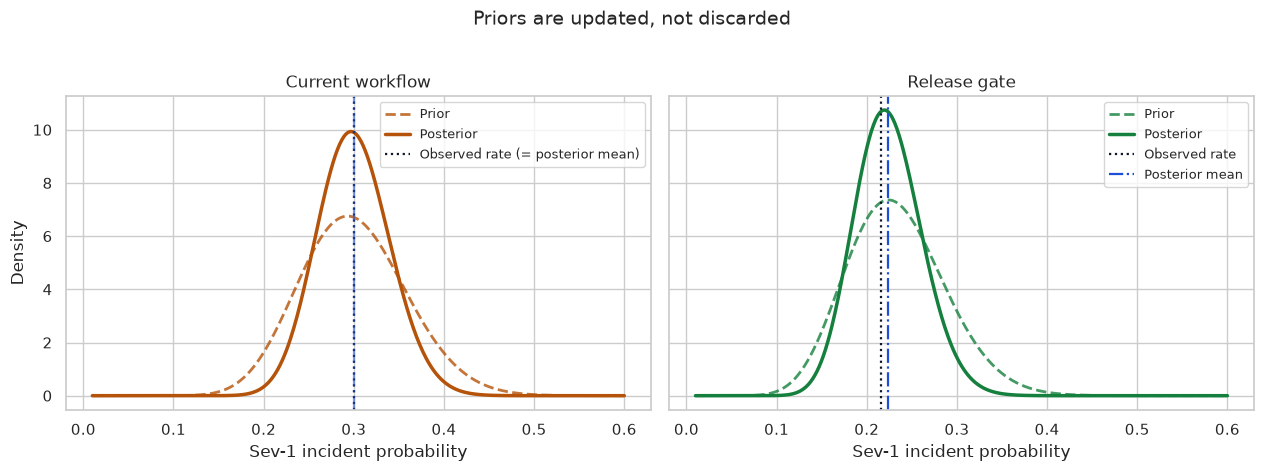

In [3]:
# Plot each arm's prior and posterior so the update is visible, not just tabulated.
x = np.linspace(0.01, 0.60, 500)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6), sharey=True)

for ax, (_, row), color in zip(axes, pilot.iterrows(), [COLORS["current"], COLORS["gate"]]):
    prior_density = beta.pdf(x, row["prior_a"], row["prior_b"])
    posterior_density = beta.pdf(x, row["posterior_a"], row["posterior_b"])
    overlap = np.isclose(row["observed_rate"], row["posterior_mean"])

    ax.plot(x, prior_density, linestyle="--", linewidth=2.0, color=color, alpha=0.8, label="Prior")
    ax.plot(x, posterior_density, linewidth=2.5, color=color, label="Posterior")

    # Vertical lines separate the raw pilot rate from the posterior mean when they differ.
    ax.axvline(
        row["observed_rate"],
        color=COLORS["baseline"],
        linestyle=":",
        linewidth=1.6,
        label="Observed rate (= posterior mean)" if overlap else "Observed rate",
    )
    ax.axvline(
        row["posterior_mean"],
        color=COLORS["posterior"],
        linestyle="-.",
        linewidth=1.6,
        alpha=0.55 if overlap else 1.0,
        label=None if overlap else "Posterior mean",
    )
    ax.set_title(row["workflow"])
    ax.set_xlabel("Sev-1 incident probability")
    ax.legend(frameon=True, fontsize=9)

axes[0].set_ylabel("Density")
fig.suptitle("Priors are updated, not discarded", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


Three things are worth noticing:

1. when the prior and the pilot differ, the posterior sits between them; when they already agree closely, the posterior mean can overlap the observed rate,
2. the posterior is tighter than the prior because the pilot adds information,
3. the gate still has substantial uncertainty, even after looking better on the raw pilot proportion.

This is a useful mindset shift. Bayesian inference does not ask whether the data “beat” the prior. It asks how the prior and data should be combined.

## 4. Posterior Probability of Improvement

The core business questions are:

- What is the probability the gate is better?
- What is the probability the improvement is practically meaningful?

We answer that by sampling from the independent posteriors of the two workflow risks and examining

$$
\delta = \theta_{\text{current}} - \theta_{\text{gate}}.
$$

Positive values of $\delta$ mean the gate reduces incident risk.


In [4]:
# Draw from each posterior and compute the implied improvement distribution.
rng = np.random.default_rng(20260614)
draws = 160_000

current_row = pilot.loc[pilot["workflow"] == "Current workflow"].iloc[0]
gate_row = pilot.loc[pilot["workflow"] == "Release gate"].iloc[0]

theta_current = beta.rvs(
    current_row["posterior_a"],
    current_row["posterior_b"],
    size=draws,
    random_state=rng,
)
theta_gate = beta.rvs(
    gate_row["posterior_a"],
    gate_row["posterior_b"],
    size=draws,
    random_state=rng,
)

# Positive delta means fewer Sev-1 incident releases under the gate.
delta = theta_current - theta_gate
relative_reduction = delta / theta_current

posterior_metrics = pd.DataFrame(
    [
        {"metric": "Posterior mean incident rate: current", "value": theta_current.mean()},
        {"metric": "Posterior mean incident rate: gate", "value": theta_gate.mean()},
        {"metric": "Posterior mean absolute reduction", "value": delta.mean()},
        {"metric": "Pr(gate is better)", "value": (delta > 0).mean()},
        {"metric": "Pr(reduction >= 5 percentage points)", "value": (delta >= 0.05).mean()},
        {"metric": "Median relative reduction", "value": np.median(relative_reduction)},
        {"metric": "90% credible interval lower bound for reduction", "value": np.quantile(delta, 0.05)},
        {"metric": "90% credible interval upper bound for reduction", "value": np.quantile(delta, 0.95)},
    ]
)

display(posterior_metrics.round(3))


,metric,value
0,Posterior mean incident rate: current,0.300
1,Posterior mean incident rate: gate,0.224
2,Posterior mean absolute reduction,0.076
3,Pr(gate is better),0.919
4,Pr(reduction >= 5 percentage points),0.686
5,Median relative reduction,0.256
6,90% credible interval lower bound for reduction,-0.014
7,90% credible interval upper bound for reduction,0.165


The posterior comparison is favorable but not absolute. The gate has a high probability of being better, and the mean reduction is operationally meaningful. At the same time, the 90% credible interval for the reduction still crosses zero, and the probability of clearing a 5-percentage-point improvement threshold is lower than the probability of any improvement. This is the distinction decision-makers usually care about: likely better is not the same as reliably large.

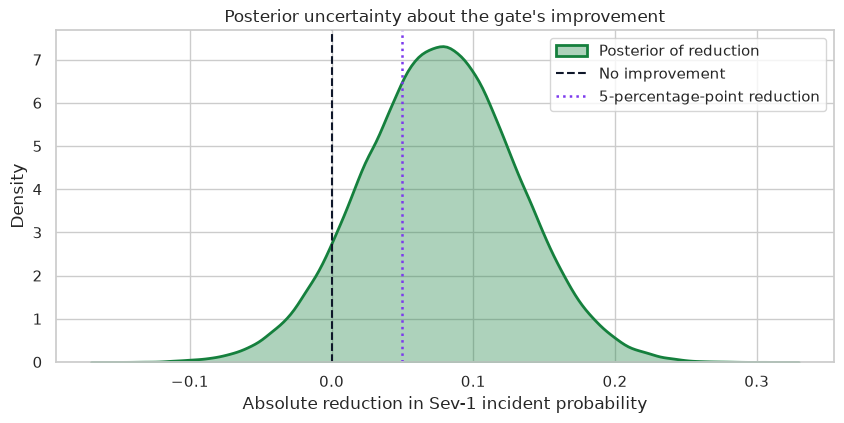

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, ax = plt.subplots(figsize=(8.6, 4.4))
sns.kdeplot(delta, fill=True, color=COLORS["gate"], linewidth=2, alpha=0.35, ax=ax, label="Posterior of reduction")
ax.axvline(0, color=COLORS["baseline"], linestyle="--", linewidth=1.5, label="No improvement")
ax.axvline(0.05, color=COLORS["accent"], linestyle=":", linewidth=1.8, label="5-percentage-point reduction")
ax.set_title("Posterior uncertainty about the gate's improvement")
ax.set_xlabel("Absolute reduction in Sev-1 incident probability")
ax.set_ylabel("Density")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


The gate looks promising, but not certain. The posterior probability of improvement is high, yet the probability of a **large** improvement is materially lower.

That distinction matters. A team might be comfortable rolling out when the intervention is *probably better*, but not when the evidence for a *meaningful* gain is still only moderate.

## 5. Posterior Predictive Forecast for the Next Quarter

Parameter uncertainty is only part of the story. Decision-makers also care about what may happen next.

For a future quarter with 60 major releases, we propagate posterior uncertainty into **predictive uncertainty** by simulating future severe-incident counts under each workflow.


In [6]:
# Convert posterior parameter uncertainty into future incident-count uncertainty.
future_releases = 60
future_current = rng.binomial(future_releases, theta_current)
future_gate = rng.binomial(future_releases, theta_gate)
future_saved = future_current - future_gate

# Summaries now refer to future observed counts, not just latent incident probabilities.
predictive_summary = pd.DataFrame(
    [
        {
            "scenario": "Current workflow",
            "posterior_predictive_mean": future_current.mean(),
            "predictive_90_lower": np.quantile(future_current, 0.05),
            "predictive_90_upper": np.quantile(future_current, 0.95),
        },
        {
            "scenario": "Release gate",
            "posterior_predictive_mean": future_gate.mean(),
            "predictive_90_lower": np.quantile(future_gate, 0.05),
            "predictive_90_upper": np.quantile(future_gate, 0.95),
        },
        {
            "scenario": "Incidents avoided by gate",
            "posterior_predictive_mean": future_saved.mean(),
            "predictive_90_lower": np.quantile(future_saved, 0.05),
            "predictive_90_upper": np.quantile(future_saved, 0.95),
        },
    ]
)

forecast_metrics = pd.DataFrame(
    [
        {
            "metric": "Pr(gate yields fewer severe-incident releases next quarter)",
            "value": (future_saved > 0).mean(),
        },
        {
            "metric": "Pr(gate avoids at least 3 severe-incident releases next quarter)",
            "value": (future_saved >= 3).mean(),
        },
    ]
)

display(predictive_summary.round(2))
display(forecast_metrics.round(3))


,scenario,posterior_predictive_mean,predictive_90_lower,predictive_90_upper
0,Current workflow,18.01,11.0,25.0
1,Release gate,13.45,7.0,20.0
2,Incidents avoided by gate,4.56,-5.0,14.0


,metric,value
0,Pr(gate yields fewer severe-incident releases next quarter),0.758
1,Pr(gate avoids at least 3 severe-incident releases next quarter),0.640


The predictive summary is wider than the parameter summary because next quarter can be lucky or unlucky even if the posterior means are right. The gate avoids about 4 to 5 severe-incident releases on average, but the 90% predictive interval for avoided incidents includes negative values. In plain language: the gate is expected to help, yet a single future quarter could still look worse by chance.

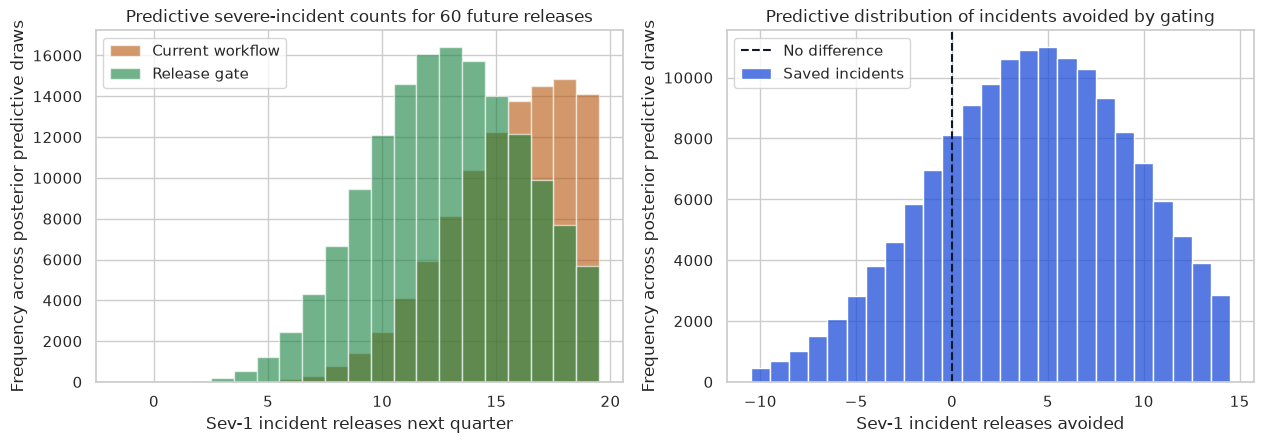

In [7]:
# Plot future count distributions for each workflow and the avoided-incident contrast.
bins = np.arange(-1, 21) - 0.5

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))

axes[0].hist(future_current, bins=bins, alpha=0.60, color=COLORS["current"], label="Current workflow")
axes[0].hist(future_gate, bins=bins, alpha=0.60, color=COLORS["gate"], label="Release gate")
axes[0].set_title("Predictive severe-incident counts for 60 future releases")
axes[0].set_xlabel("Sev-1 incident releases next quarter")
axes[0].set_ylabel("Frequency across posterior predictive draws")
axes[0].legend(frameon=True)

sns.histplot(
    future_saved,
    bins=np.arange(-10, 16) - 0.5,
    color=COLORS["posterior"],
    ax=axes[1],
    label="Saved incidents",
)
axes[1].axvline(0, color=COLORS["baseline"], linestyle="--", linewidth=1.5, label="No difference")
axes[1].set_title("Predictive distribution of incidents avoided by gating")
axes[1].set_xlabel("Sev-1 incident releases avoided")
axes[1].set_ylabel("Frequency across posterior predictive draws")
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


The predictive distributions are broader than the posterior distributions on incident **rates** because they include both:

- uncertainty about the true incident probability, and
- fresh randomness in next quarter's realized releases.

This is exactly why predictive reasoning is useful in decision settings. Stakeholders experience future outcomes, not latent parameters. That is also why the predictive distribution of incidents avoided still leaves visible probability mass below zero even when the posterior mean effect is favorable.

## 6. A Utility-Based Rollout Decision

Suppose leadership evaluates rollout over the next 18 months:

- about **280 major releases** are expected,
- each avoided Sev-1 launch incident saves roughly **\$100,000** in downstream support, customer credits, and engineering interruption,
- organization-wide rollout of the gate costs **\$1.4 million**.

We define the incremental net value of rolling out the gate as

$$
V = 280 \times 100{,}000 \times (\theta_{\text{current}} - \theta_{\text{gate}}) - 1{,}400{,}000.
$$

Positive values of $V$ favor rollout.


In [8]:
# Translate posterior improvement draws into a rollout value distribution.
planning_horizon = 280
cost_per_sev1 = 100_000
rollout_cost = 1_400_000

net_value_rollout = planning_horizon * cost_per_sev1 * delta - rollout_cost

# These metrics separate expected value from downside and upside risk.
decision_metrics = pd.DataFrame(
    [
        {"metric": "Expected net value of rollout ($M)", "value": net_value_rollout.mean() / 1_000_000},
        {"metric": "Pr(net value > 0)", "value": (net_value_rollout > 0).mean()},
        {"metric": "Pr(net value > $1M)", "value": (net_value_rollout > 1_000_000).mean()},
        {"metric": "10th percentile net value ($M)", "value": np.quantile(net_value_rollout, 0.10) / 1_000_000},
        {"metric": "90th percentile net value ($M)", "value": np.quantile(net_value_rollout, 0.90) / 1_000_000},
    ]
)

# Different stakeholders can use the same posterior but impose different action criteria.
stakeholder_rules = pd.DataFrame(
    [
        {
            "stakeholder_rule": "Risk-neutral finance rule",
            "criterion": "Roll out if expected net value > 0",
            "result": "Roll out" if net_value_rollout.mean() > 0 else "Do not roll out",
        },
        {
            "stakeholder_rule": "Risk-controlled reliability rule",
            "criterion": "Roll out if Pr(net value > 0) >= 0.75",
            "result": "Roll out" if (net_value_rollout > 0).mean() >= 0.75 else "Collect more evidence",
        },
        {
            "stakeholder_rule": "Practical-effect rule",
            "criterion": "Roll out if Pr(reduction >= 5 percentage points) >= 0.70",
            "result": "Roll out" if (delta >= 0.05).mean() >= 0.70 else "Collect more evidence",
        },
    ]
)

display(decision_metrics.round(3))
display(stakeholder_rules)


,metric,value
0,Expected net value of rollout ($M),0.732
1,Pr(net value > 0),0.686
2,Pr(net value > $1M),0.431
3,10th percentile net value ($M),-1.218
4,90th percentile net value ($M),2.678


,stakeholder_rule,criterion,result
0,Risk-neutral finance rule,Roll out if expected net value > 0,Roll out
1,Risk-controlled reliability rule,Roll out if Pr(net value > 0) >= 0.75,Collect more evidence
2,Practical-effect rule,Roll out if Pr(reduction >= 5 percentage points) >= 0.70,Collect more evidence


The expected net value is positive, so a risk-neutral rule recommends rollout. But the probability of positive net value does not clear the 0.75 reliability threshold, and the probability of at least a 5-percentage-point reduction is just below its practical-effect threshold. This is a good example of Bayesian decision analysis: the posterior does not mechanically produce one answer. It lets the organization see exactly which risk tolerance is driving the recommendation.

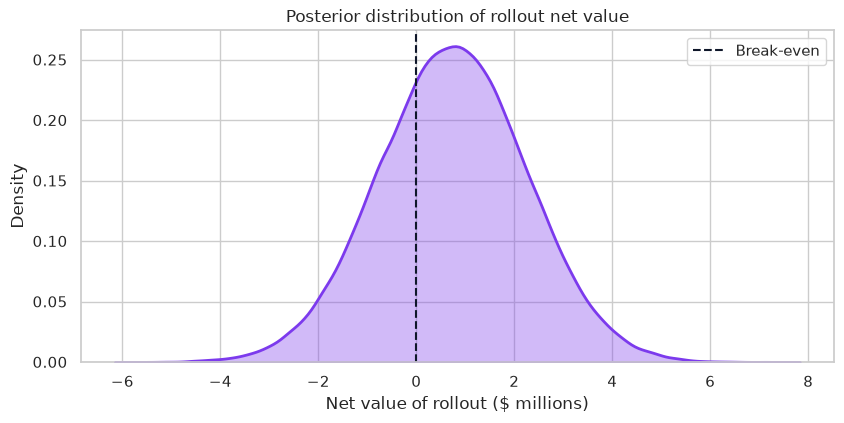

In [9]:
# Visualize the rollout value distribution and the break-even point.
fig, ax = plt.subplots(figsize=(8.6, 4.4))
sns.kdeplot(net_value_rollout / 1_000_000, fill=True, color=COLORS["accent"], alpha=0.35, linewidth=2, ax=ax)
ax.axvline(0, color=COLORS["baseline"], linestyle="--", linewidth=1.5, label="Break-even")
ax.set_title("Posterior distribution of rollout net value")
ax.set_xlabel("Net value of rollout ($ millions)")
ax.set_ylabel("Density")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


This section shows why Bayesian inference is especially useful in decision work:

- the **risk-neutral** rule focuses on average net value and supports rollout,
- the **risk-controlled** rule asks whether downside probability is small enough and, in this run, still prefers more pilot evidence,
- the **practical-effect** rule focuses on whether the gain is large enough to matter operationally and also remains just short of its threshold in this run.

None of these rules is “the Bayesian answer” by itself. The posterior is shared, but the recommended action depends on the utility or loss structure.

## 7. Prior Sensitivity

A fair Bayesian analysis should check whether the decision depends heavily on a narrow prior choice.

We keep the current-workflow prior fixed and vary the prior for the release gate:

- **Skeptical:** the gate is no better *a priori* than the current workflow,
- **Moderate:** mild prior optimism,
- **Enthusiastic:** stronger prior optimism.


In [10]:
# Recompute posterior and value metrics under alternative gate priors.
prior_scenarios = pd.DataFrame(
    [
        {"scenario": "Skeptical", "gate_prior_a": 18, "gate_prior_b": 42},
        {"scenario": "Moderate", "gate_prior_a": 14, "gate_prior_b": 46},
        {"scenario": "Enthusiastic", "gate_prior_a": 10, "gate_prior_b": 50},
    ]
)

sensitivity_rows = []
for _, row in prior_scenarios.iterrows():
    gate_post_a, gate_post_b = beta_posterior(
        row["gate_prior_a"], row["gate_prior_b"], gate_row["sev1_releases"], gate_row["n_releases"]
    )
    current_post_a, current_post_b = beta_posterior(
        current_row["prior_a"], current_row["prior_b"], current_row["sev1_releases"], current_row["n_releases"]
    )

    # Use the same simulation machinery so differences come from prior assumptions, not method changes.
    theta_current_s = beta.rvs(current_post_a, current_post_b, size=draws, random_state=rng)
    theta_gate_s = beta.rvs(gate_post_a, gate_post_b, size=draws, random_state=rng)
    delta_s = theta_current_s - theta_gate_s
    utility_s = planning_horizon * cost_per_sev1 * delta_s - rollout_cost

    sensitivity_rows.append(
        {
            "scenario": row["scenario"],
            "gate_prior_mean": row["gate_prior_a"] / (row["gate_prior_a"] + row["gate_prior_b"]),
            "posterior_mean_reduction": delta_s.mean(),
            "Pr(gate better)": (delta_s > 0).mean(),
            "Pr(reduction >= 5 points)": (delta_s >= 0.05).mean(),
            "expected_net_value_millions": utility_s.mean() / 1_000_000,
            "Pr(net value > 0)": (utility_s > 0).mean(),
        }
    )

sensitivity_table = pd.DataFrame(sensitivity_rows)
display(sensitivity_table.round(3))


,scenario,gate_prior_mean,posterior_mean_reduction,Pr(gate better),Pr(reduction >= 5 points),expected_net_value_millions,Pr(net value > 0)
0,Skeptical,0.300,0.044,0.787,0.458,-0.167,0.458
1,Moderate,0.233,0.076,0.918,0.682,0.722,0.682
2,Enthusiastic,0.167,0.108,0.978,0.862,1.616,0.862


The sensitivity table shows that the qualitative conclusion depends on how much optimism the organization is willing to encode before seeing the pilot. Under the skeptical prior, the gate can still be probably better while having negative expected value after rollout costs. Under the enthusiastic prior, both the posterior probability and expected net value become much stronger. That spread is not a failure of Bayesian analysis. It is a prompt to discuss whether the prior assumptions are defensible.

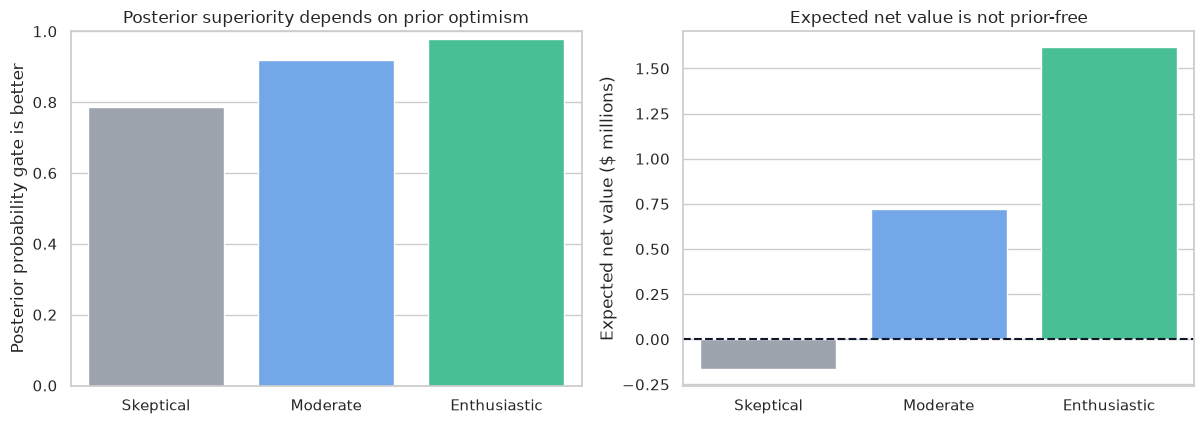

In [11]:
# Compare how prior assumptions affect posterior superiority and expected value.
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.4))

# Left panel: probability statement about superiority.
sns.barplot(
    data=sensitivity_table,
    x="scenario",
    y="Pr(gate better)",
    hue="scenario",
    palette=["#9ca3af", "#60a5fa", "#34d399"],
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_ylim(0, 1)
axes[0].set_title("Posterior superiority depends on prior optimism")
axes[0].set_xlabel("")
axes[0].set_ylabel("Posterior probability gate is better")

# Right panel: decision-scale value after rollout costs.
sns.barplot(
    data=sensitivity_table,
    x="scenario",
    y="expected_net_value_millions",
    hue="scenario",
    palette=["#9ca3af", "#60a5fa", "#34d399"],
    dodge=False,
    legend=False,
    ax=axes[1],
)
axes[1].axhline(0, color=COLORS["baseline"], linestyle="--", linewidth=1.5)
axes[1].set_title("Expected net value is not prior-free")
axes[1].set_xlabel("")
axes[1].set_ylabel("Expected net value ($ millions)")

plt.tight_layout()
plt.show()


Prior sensitivity is not a flaw to hide. It is often an important part of the decision itself.

If a rollout is attractive only under optimistic priors, then the organization may reasonably want:

- more pilot data,
- a cheaper rollout plan,
- or a narrower decision horizon.

Bayesian analysis makes these dependencies visible explicitly.

## 8. Sequential Learning During the Pilot

One practical advantage of Bayesian updating is that it can be read sequentially. As each batch of releases arrives, we can update the posterior probability that the gate is better.


In [12]:
# Shuffle the observed outcomes to create one possible accumulation path through the pilot.
current_outcomes = np.array([1] * int(current_row["sev1_releases"]) + [0] * int(current_row["n_releases"] - current_row["sev1_releases"]))
gate_outcomes = np.array([1] * int(gate_row["sev1_releases"]) + [0] * int(gate_row["n_releases"] - gate_row["sev1_releases"]))

sequence_rng = np.random.default_rng(404)
sequence_rng.shuffle(current_outcomes)
sequence_rng.shuffle(gate_outcomes)

checkpoints = list(range(5, 66, 5))
sequential_rows = []

for gate_n in checkpoints:
    current_n = min(gate_n, len(current_outcomes))
    current_successes = current_outcomes[:current_n].sum()
    gate_successes = gate_outcomes[:gate_n].sum()

    # At each checkpoint, update both arms using only evidence available so far.
    post_current_a, post_current_b = beta_posterior(
        current_row["prior_a"], current_row["prior_b"], current_successes, current_n
    )
    post_gate_a, post_gate_b = beta_posterior(
        gate_row["prior_a"], gate_row["prior_b"], gate_successes, gate_n
    )

    theta_current_seq = beta.rvs(post_current_a, post_current_b, size=40_000, random_state=rng)
    theta_gate_seq = beta.rvs(post_gate_a, post_gate_b, size=40_000, random_state=rng)
    delta_seq = theta_current_seq - theta_gate_seq

    sequential_rows.append(
        {
            "gate_releases_observed": gate_n,
            "current_releases_observed": current_n,
            "Pr(gate better)": (delta_seq > 0).mean(),
            "posterior_mean_reduction": delta_seq.mean(),
        }
    )

sequential_table = pd.DataFrame(sequential_rows)
display(sequential_table.round(3))


,gate_releases_observed,current_releases_observed,Pr(gate better),posterior_mean_reduction
0,5,5,0.724,0.046
1,10,10,0.877,0.086
2,15,15,0.872,0.080
3,20,20,0.896,0.088
4,25,25,0.896,0.082
5,30,30,0.918,0.090
6,35,35,0.908,0.084
7,40,40,0.931,0.090
8,45,45,0.924,0.085
9,50,50,0.955,0.100


The sequential table shows why teams should predefine interim rules before reacting to each new fluctuation. The posterior probability rises quickly after the early pilot batches, but the estimated mean reduction still moves around as new incidents arrive. Bayesian updating makes it natural to monitor evidence over time, but monitoring still needs governance so that temporary swings do not become ad hoc launch decisions.

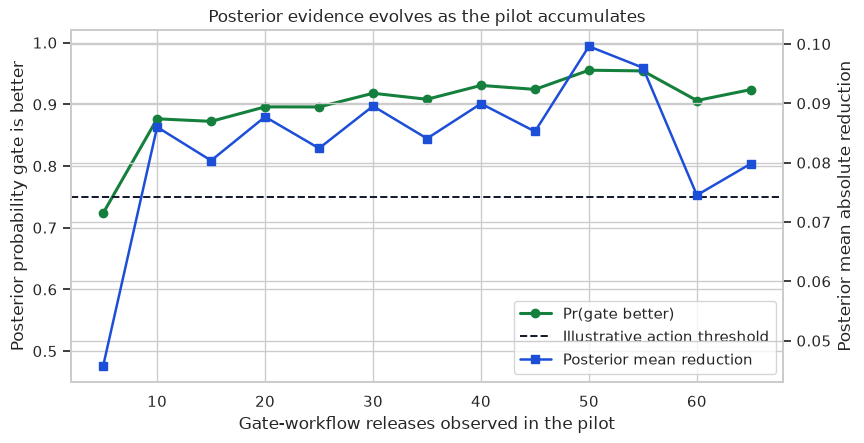

In [13]:
# Plot two sequential summaries: confidence that the gate is better and expected effect size.
fig, ax1 = plt.subplots(figsize=(8.8, 4.6))

ax1.plot(
    sequential_table["gate_releases_observed"],
    sequential_table["Pr(gate better)"],
    marker="o",
    color=COLORS["gate"],
    linewidth=2.2,
    label="Pr(gate better)",
)
ax1.axhline(0.75, color=COLORS["baseline"], linestyle="--", linewidth=1.4, label="Illustrative action threshold")
ax1.set_xlabel("Gate-workflow releases observed in the pilot")
ax1.set_ylabel("Posterior probability gate is better")
ax1.set_ylim(0.45, 1.02)

# A second axis keeps the probability scale separate from the percentage-point reduction scale.
ax2 = ax1.twinx()
ax2.plot(
    sequential_table["gate_releases_observed"],
    sequential_table["posterior_mean_reduction"],
    marker="s",
    color=COLORS["posterior"],
    linewidth=1.8,
    label="Posterior mean reduction",
)
ax2.set_ylabel("Posterior mean absolute reduction")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=True, loc="lower right")
ax1.set_title("Posterior evidence evolves as the pilot accumulates")

plt.tight_layout()
plt.show()


The sequential view is helpful for operational governance. It shows the final answer and **when** evidence becomes persuasive.

That matters when organizations stage deployments, pause pilots, or set pre-specified escalation rules for more evidence collection.

<!-- real-data-companion-course01 -->
## Real-Data Companion: Bayesian Decision Framing with RAND HIE

For a simple Bayesian companion, we convert RAND HIE utilization into a binary outcome: whether a person had at least one outpatient physician visit. This keeps the model transparent while preserving a real policy-relevant measurement scale.

The unit is a person-period record. The outcome is any outpatient use, derived from `mdvis`, and the main comparison is free care versus cost sharing based on `lncoins`. A beta-binomial model gives a posterior distribution for each group's use probability and a posterior probability that free care increases access.

The experiment is intentionally small. It does not replace a full Bayesian health-policy model with covariates, costs, and hierarchical structure. It shows how Bayesian reporting can answer a decision-facing question directly: how probable is the direction of benefit, and how large might it be under the model?

Data source: [RAND Health Insurance Experiment in statsmodels](https://www.statsmodels.org/stable/datasets/generated/randhie.html).

,group,n_people,observed_any_visit_rate,posterior_mean,posterior_lower,posterior_upper
0,Free care,10997.0,0.7210,0.7209,0.7125,0.7293
1,Cost sharing,9193.0,0.6476,0.6475,0.6377,0.6572
2,Free care minus cost sharing,NaN,NaN,0.0735,0.0606,0.0863


Posterior probability that free care increases any-visit rate: 1.000


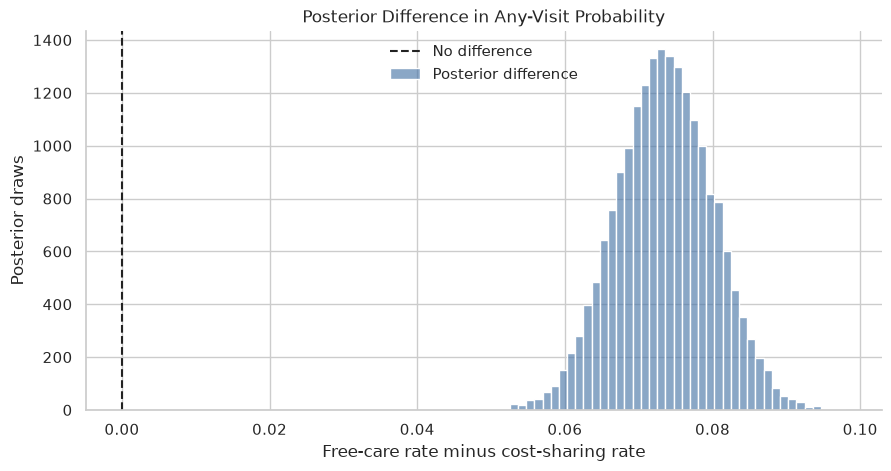

In [14]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import beta


def _find_project_root(start=Path.cwd()):
    """
    Find the nearest project root that exposes shared notebook helpers.

    Parameters:
        start: Directory from which the upward search begins, usually the current notebook working directory.

    Returns:
        The closest parent path containing `notebooks/_shared`; returns `start` when the helper directory is unavailable.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_randhie, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    rng_real = np.random.default_rng(2026)
    rand_hie = load_statsmodels_randhie().copy()

    # Convert plan assignment and utilization into a simple beta-binomial comparison.
    rand_hie["coinsurance"] = np.expm1(rand_hie["lncoins"]).round().clip(0, 100)
    rand_hie["free_care"] = rand_hie["coinsurance"].eq(0).astype(int)
    rand_hie["any_visit"] = rand_hie["mdvis"].gt(0).astype(int)

    prior_a, prior_b = 2, 2
    post_rows = []
    samples = {}
    groups = {"Free care": rand_hie.query("free_care == 1"), "Cost sharing": rand_hie.query("free_care == 0")}

    for label, group in groups.items():
        successes = int(group["any_visit"].sum())
        trials = int(len(group))
        failures = trials - successes
        a_post = prior_a + successes
        b_post = prior_b + failures
        samples[label] = rng_real.beta(a_post, b_post, size=20_000)
        post_rows.append(
            {
                "group": label,
                "n_people": trials,
                "observed_any_visit_rate": successes / trials,
                "posterior_mean": a_post / (a_post + b_post),
                "posterior_lower": beta.ppf(0.025, a_post, b_post),
                "posterior_upper": beta.ppf(0.975, a_post, b_post),
            }
        )

    posterior_diff = samples["Free care"] - samples["Cost sharing"]
    decision_summary = pd.DataFrame(
        post_rows
        + [
            {
                "group": "Free care minus cost sharing",
                "n_people": np.nan,
                "observed_any_visit_rate": np.nan,
                "posterior_mean": posterior_diff.mean(),
                "posterior_lower": np.quantile(posterior_diff, 0.025),
                "posterior_upper": np.quantile(posterior_diff, 0.975),
            }
        ]
    )
    smart_display(decision_summary.round(4))
    print(f"Posterior probability that free care increases any-visit rate: {(posterior_diff > 0).mean():.3f}")

    fig, ax = plt.subplots(figsize=(8.8, 4.6), constrained_layout=True)
    sns.histplot(
        posterior_diff,
        bins=45,
        color="#4C78A8",
        alpha=0.65,
        ax=ax,
        label="Posterior difference",
    )
    ax.axvline(0, color="#222222", linestyle="--", linewidth=1.5, label="No difference")
    ax.set_title("Posterior Difference in Any-Visit Probability")
    ax.set_xlabel("Free-care rate minus cost-sharing rate")
    ax.set_ylabel("Posterior draws")
    ax.legend(frameon=False)
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "RAND Health Insurance Experiment",
        "https://www.statsmodels.org/stable/datasets/generated/randhie.html",
        "RUN_REAL_DATA_COMPANION",
    )


<!-- real-data-companion-course01 -->
The RAND example gives the same Bayesian decision pattern on real data. The posterior difference is clearly above zero, so this simple model assigns essentially all posterior mass to higher any-visit rates under free care. The limitation is equally important: this is a direct two-group beta-binomial summary, not a full causal adjustment for the RAND design, plan variation, or repeated utilization behavior. It is best treated as a compact demonstration of how a decision probability is formed from a prior, a likelihood, and observed counts.

## What to Remember

- Bayesian inference combines prior knowledge and observed data through the posterior.
- Credible intervals describe posterior uncertainty about parameters, not future outcomes.
- Posterior predictive distributions are often more decision-relevant than parameter summaries alone.
- The same posterior can support different actions under different utility or risk rules.
- Prior sensitivity is a feature of transparent decision analysis, not an embarrassment.

In the next notebook, we will push further on checking models and evaluating whether these probabilistic summaries are actually trustworthy.


## References

- Lee, J. C., & Sabavala, D. J. (1987). *Bayesian estimation and prediction for the Beta-Binomial model.* *Journal of Business & Economic Statistics, 5*(3), 357-367. [https://doi.org/10.1080/07350015.1987.10509600](https://doi.org/10.1080/07350015.1987.10509600)
- Lindley, D. V., & Smith, A. F. M. (1972). *Bayes estimates for the linear model.* *Journal of the Royal Statistical Society: Series B (Methodological), 34*(1), 1-18. [https://doi.org/10.1111/j.2517-6161.1972.tb00885.x](https://doi.org/10.1111/j.2517-6161.1972.tb00885.x)
- Strayhorn, J. C., Collins, L. M., & Vanness, D. J. (2024). *A posterior expected value approach to decision-making in the multiphase optimization strategy for intervention science.* *Psychological Methods, 29*(4), 656-678. [https://doi.org/10.1037/met0000569](https://doi.org/10.1037/met0000569)
- Williams, P. J., & Hooten, M. B. (2016). *Combining statistical inference and decisions in ecology.* *Ecological Applications, 26*(6), 1930-1942. [https://doi.org/10.1890/15-1593.1](https://doi.org/10.1890/15-1593.1)
